In [8]:
from dataclasses import dataclass

@dataclass(frozen=True)
class Observation:
    hr: int
    bp: int
    temp: float
    resp: float
    ox_sats: float
    insp_ox: float

In [9]:
obs_1 = Observation(hr=52, bp=102, temp=36.2, resp=22, ox_sats=94, insp_ox=30)

In [10]:
class membership_function:
    def __init__(self, mfs):
        self.mfs = mfs
        self.labels = list(mfs.keys())
        
    def __call__(self, inp):
        results = {}
        
        for label, params in self.mfs.items():
            a = params['a']
            b = params['b']
            c = params['c']
            d = params['d']
            
            if inp <= a:
                membership = 0
            elif inp > a and inp < b:
                membership = (inp - a) / (b - a)
            elif inp >= b and inp <= c:
                membership = 1
            elif inp > c and inp < d:
                membership = (d - inp) / (d - c)
            else:
                membership = 0
                
            results[label] = membership
        
        return results

In [11]:
hr_mf = {
    'low':    {'a': 20, 'b': 20, 'c': 50,  'd': 60},
    'normal': {'a': 50, 'b': 60, 'c': 90,  'd': 100},
    'high':   {'a': 90, 'b': 100,'c': 200, 'd': 200}
}

fio2_mf = {
    'normal': {'a': 20, 'b': 20, 'c': 24, 'd': 28},
    'mild':   {'a': 24, 'b': 28, 'c': 40, 'd': 50},
    'high':   {'a': 40, 'b': 50, 'c': 100,'d': 100}
}

spo2_mf = {
    'low':    {'a': 50, 'b': 50, 'c': 90,  'd': 92},
    'normal': {'a': 90, 'b': 94, 'c': 98,  'd': 100},
    'high':   {'a': 98, 'b': 100,'c': 100, 'd': 100}
}

supp_o2_mf = {
    'none': {'a': 0, 'b': 0, 'c': 1, 'd': 2},
    'low':  {'a': 1, 'b': 2, 'c': 4, 'd': 6},
    'high': {'a': 4, 'b': 6, 'c': 15,'d': 15}
}


rr_mf = {
    'low':    {'a': 0,  'b': 0,  'c': 10, 'd': 12},
    'normal': {'a': 10, 'b': 12, 'c': 20, 'd': 22},
    'high':   {'a': 20, 'b': 24, 'c': 60, 'd': 60}
}

sbp_mf = {
    'low':    {'a': 40, 'b': 40, 'c': 90,  'd': 100},
    'normal': {'a': 90, 'b': 110,'c': 130, 'd': 140},
    'high':   {'a': 130,'b': 150,'c': 250, 'd': 250}
}

temp_mf = {
    'low':    {'a': 30,  'b': 30,  'c': 35.5, 'd': 36},
    'normal': {'a': 35.5,'b': 36.5,'c': 37.5, 'd': 38},
    'high':   {'a': 37.5,'b': 38.5,'c': 42,   'd': 42}
}




hr = membership_function(hr_mf)


hr(50)

{'low': 1, 'normal': 0, 'high': 0}

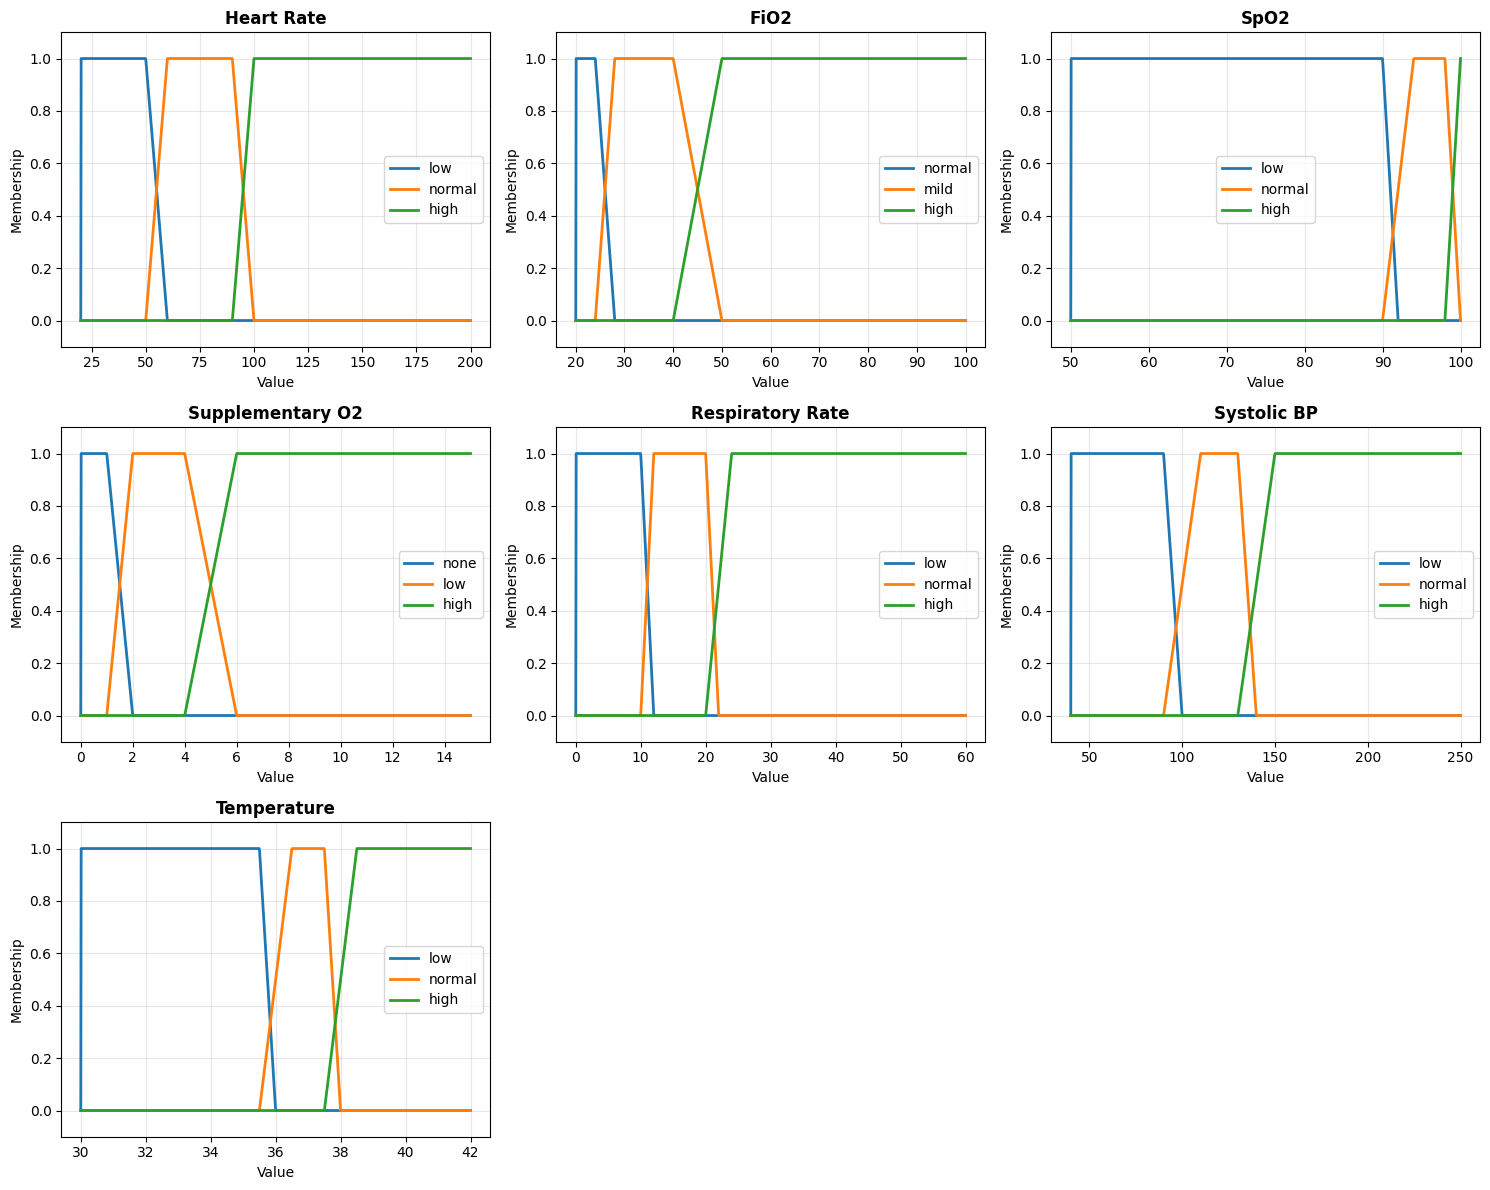

In [12]:
import numpy as np

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

mf_dict = {
    'Heart Rate': hr_mf,
    'FiO2': fio2_mf,
    'SpO2': spo2_mf,
    'Supplementary O2': supp_o2_mf,
    'Respiratory Rate': rr_mf,
    'Systolic BP': sbp_mf,
    'Temperature': temp_mf
}

for idx, (name, mf_params) in enumerate(mf_dict.items()):
    ax = axes[idx]
    
    # Determine the range for x-axis
    all_values = [v for params in mf_params.values() for v in params.values()]
    x_min, x_max = min(all_values), max(all_values)
    x = np.linspace(x_min, x_max, 1000)
    
    # Plot each membership function
    for label, params in mf_params.items():
        a, b, c, d = params['a'], params['b'], params['c'], params['d']
        y = np.zeros_like(x)
        
        for i, val in enumerate(x):
            if val <= a:
                y[i] = 0
            elif val > a and val < b:
                y[i] = (val - a) / (b - a)
            elif val >= b and val <= c:
                y[i] = 1
            elif val > c and val < d:
                y[i] = (d - val) / (d - c)
            else:
                y[i] = 0
        
        ax.plot(x, y, label=label, linewidth=2)
    
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Membership')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.1, 1.1)

# Hide unused subplots
for idx in range(len(mf_dict), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [13]:
# Inference engine
def inference_engine(obs):
    # Fuzzify inputs
    hr_fuzzy = membership_function(hr_mf)(obs.hr)
    temp_fuzzy = membership_function(temp_mf)(obs.temp)
    rr_fuzzy = membership_function(rr_mf)(obs.resp)
    sbp_fuzzy = membership_function(sbp_mf)(obs.bp)
    spo2_fuzzy = membership_function(spo2_mf)(obs.ox_sats)
    fio2_fuzzy = membership_function(fio2_mf)(obs.insp_ox)
    
    # Rule base (simplified example - you should expand this)
    rules = []
    
    # High risk rules
    rules.append(min(hr_fuzzy['low'], temp_fuzzy['low']))  # Low HR and low temp -> high risk
    rules.append(min(hr_fuzzy['high'], temp_fuzzy['high']))  # High HR and high temp -> high risk
    rules.append(min(spo2_fuzzy['low'], fio2_fuzzy['high']))  # Low SpO2 with high FiO2 -> high risk
    
    # Medium risk rules
    rules.append(min(hr_fuzzy['normal'], temp_fuzzy['high']))  # Normal HR but high temp -> medium risk
    rules.append(min(rr_fuzzy['high'], sbp_fuzzy['normal']))  # High RR, normal BP -> medium risk
    
    # Low risk rules
    rules.append(min(hr_fuzzy['normal'], temp_fuzzy['normal'], rr_fuzzy['normal'], sbp_fuzzy['normal'], spo2_fuzzy['normal']))
    
    # Aggregate rules (max for OR operation)
    high_risk = max(rules[0], rules[1], rules[2])
    medium_risk = max(rules[3], rules[4])
    low_risk = rules[5]
    
    return {'low': low_risk, 'medium': medium_risk, 'high': high_risk}

# Defuzzification using centroid method
def defuzzify(fuzzy_output):
    # Define risk score ranges
    risk_scores = {'low': 0, 'medium': 50, 'high': 100}
    
    numerator = sum(fuzzy_output[label] * risk_scores[label] for label in fuzzy_output)
    denominator = sum(fuzzy_output.values())
    
    if denominator == 0:
        return 0
    
    return numerator / denominator

# Test with obs_1
fuzzy_result = inference_engine(obs_1)
risk_score = defuzzify(fuzzy_result)

print("Fuzzy output:", fuzzy_result)
print("Risk score:", risk_score)

Fuzzy output: {'low': 0, 'medium': 0.5, 'high': 0}
Risk score: 50.0


Loading dataset...


/tmp/ipykernel_148464/2383953725.py:8: DtypeWarning: Columns (7,10) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/msxtk13/Documents/FuzzySystemMain/20250630_final_observations-sorted_V7_training.csv')


Dataset loaded: 9600033 rows
Using first 50000 rows
Processed 48468 observations

First few comparisons:
   news2_score  fuzzy_score  high_risk_actual  fuzzy_prediction
0          3.0          0.0                 0                 0
1          4.0          0.0                 0                 0
2          2.0          0.0                 0                 0
3          3.0          0.0                 0                 0
4          3.0          0.0                 0                 0
5          3.0          0.0                 0                 0
6          1.0          0.0                 0                 0
7          0.0          0.0                 0                 0
8          0.0          0.0                 0                 0
9          0.0          0.0                 0                 0


/tmp/ipykernel_148464/2383953725.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(box_data, labels=['Low Risk\n(NEWS-2 < 5)', 'High Risk\n(NEWS-2 ≥ 5)'], patch_artist=True)


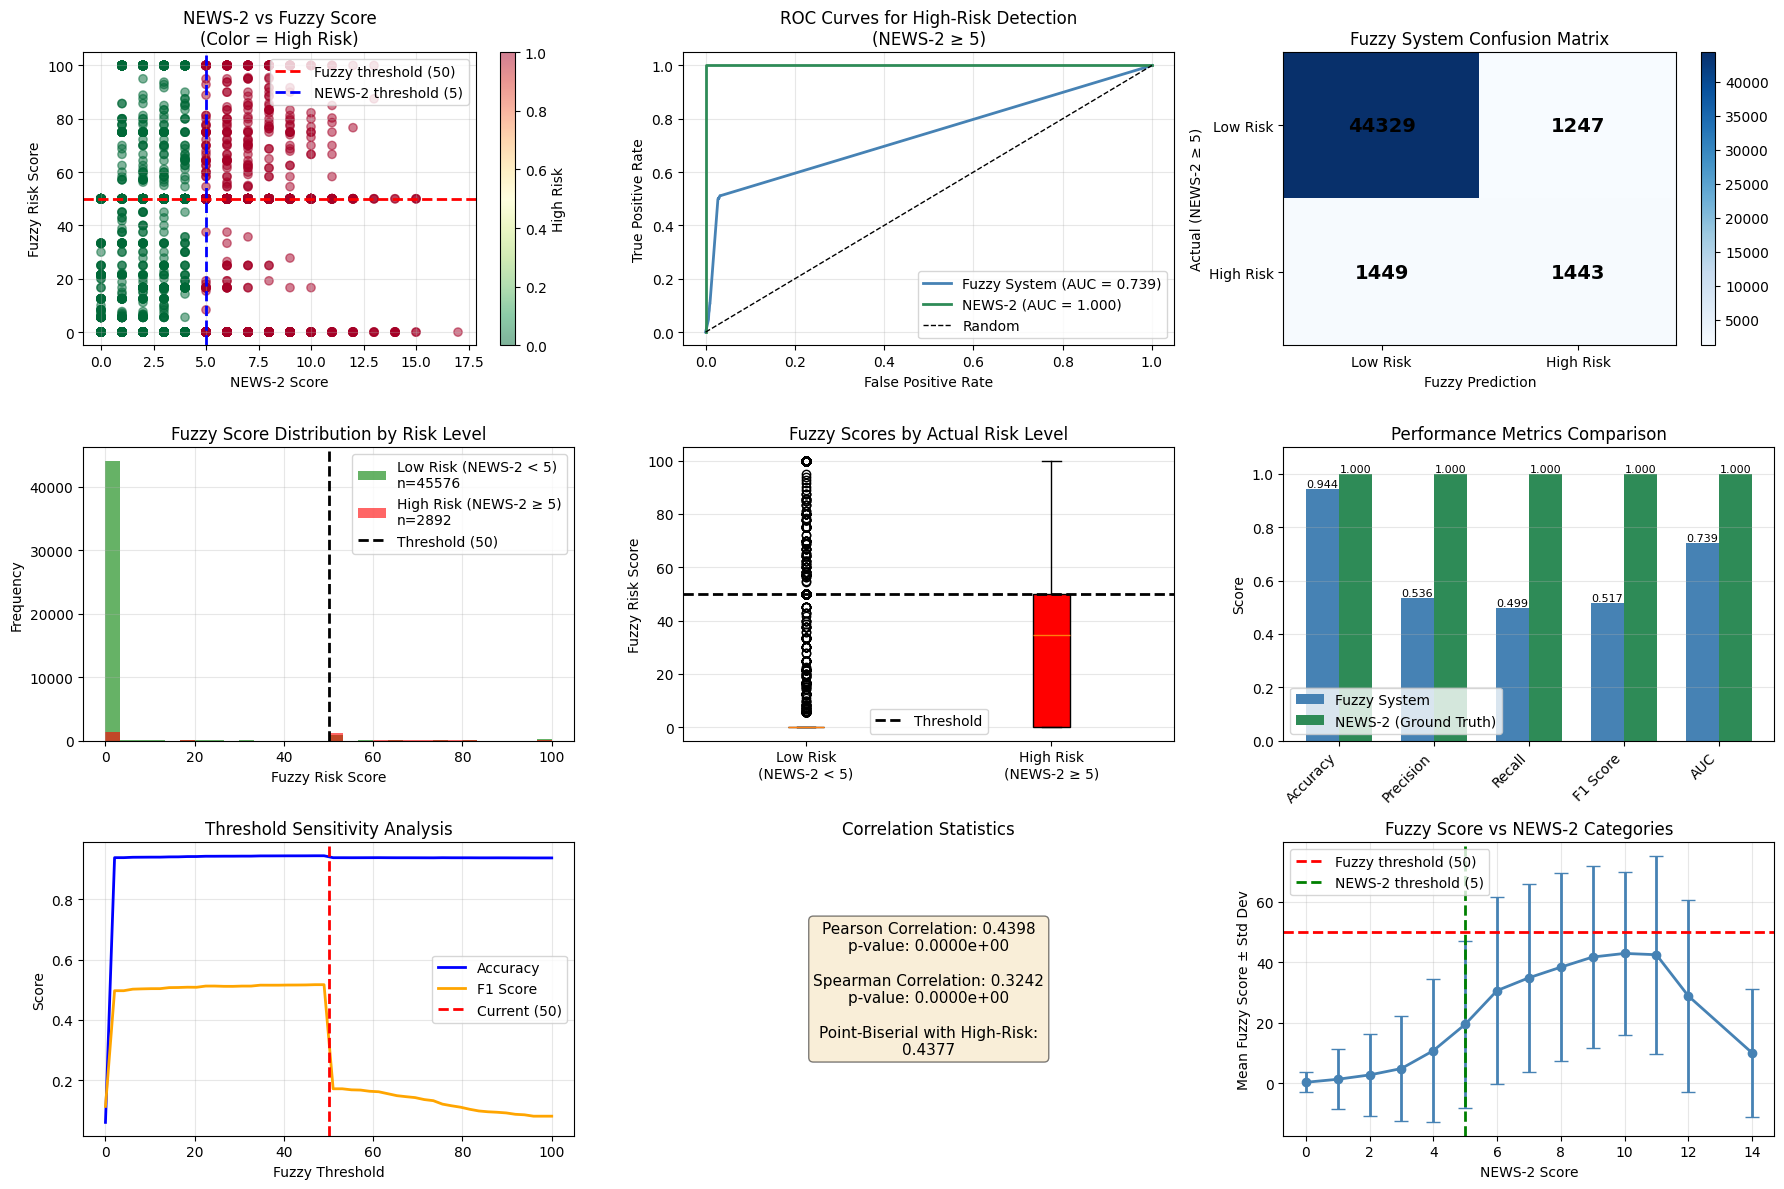


COMPREHENSIVE COMPARISON SUMMARY

Dataset Statistics:
  Total observations: 48468
  High-risk cases (NEWS-2 ≥ 5): 2892 (5.97%)
  Low-risk cases (NEWS-2 < 5): 45576 (94.03%)

Fuzzy Score Statistics:
  Mean: 3.52
  Std Dev: 14.67
  Min: 0.00
  Max: 100.00
  Median: 0.00

Fuzzy Score by Risk Level:
  Low Risk (NEWS-2 < 5):
    Mean: 1.90 ± 11.17
    Median: 0.00
  High Risk (NEWS-2 ≥ 5):
    Mean: 29.00 ± 30.78
    Median: 34.52

Correlation Analysis:
  Pearson correlation: 0.4398 (p = 0.0000e+00)
  Spearman correlation: 0.3242 (p = 0.0000e+00)

Fuzzy System Performance (threshold = 50):
  Accuracy:  0.9444
  Precision: 0.5364
  Recall:    0.4990
  F1 Score:  0.5170
  AUC:       0.7394

NEWS-2 Performance (as ground truth):
  AUC:       1.0000

Classification Report (Fuzzy System):
              precision    recall  f1-score   support

    Low Risk       0.97      0.97      0.97     45576
   High Risk       0.54      0.50      0.52      2892

    accuracy                           0.94  

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

# Load the dataset
print("Loading dataset...")
data = pd.read_csv('/home/msxtk13/Documents/FuzzySystemMain/20250630_final_observations-sorted_V7_training.csv')
print(f"Dataset loaded: {len(data)} rows")

# Limit to first 50k rows
data = data.head(50000)
print(f"Using first {len(data)} rows")

# Helper function to parse inspired oxygen
def parse_inspired_o2(val):
    if pd.isna(val):
        return 21.0
    val_str = str(val)
    if 'Air' in val_str or 'air' in val_str:
        return 21.0
    try:
        return float(val_str.replace('%', '').strip())
    except:
        return 21.0

# Calculate fuzzy scores for each observation
fuzzy_scores = []
news2_scores = []

for idx, row in data.iterrows():
    # Skip rows with missing values (using correct column names)
    if pd.isna(row['HEART_RATE']) or pd.isna(row['SYSTOLIC_BP']) or pd.isna(row['TEMPERATURE']) or pd.isna(row['RESP_RATE']) or pd.isna(row['SATS_SPO2']) or pd.isna(row['NEWS-2']):
        continue
    
    # Parse inspired oxygen
    insp_ox = parse_inspired_o2(row['INSPIRED_O2_TEXT'])
    
    # Create observation from row data
    obs = Observation(
        hr=int(row['HEART_RATE']),
        bp=int(row['SYSTOLIC_BP']),
        temp=float(row['TEMPERATURE']),
        resp=float(row['RESP_RATE']),
        ox_sats=float(row['SATS_SPO2']),
        insp_ox=insp_ox
    )
    
    # Calculate fuzzy risk score
    fuzzy_result = inference_engine(obs)
    risk_score = defuzzify(fuzzy_result)
    fuzzy_scores.append(risk_score)
    
    # Store raw NEWS-2 score
    news2_scores.append(row['NEWS-2'])

print(f"Processed {len(fuzzy_scores)} observations")

# Create a filtered dataframe with only complete observations
data_filtered = data.dropna(subset=['HEART_RATE', 'SYSTOLIC_BP', 'TEMPERATURE', 'RESP_RATE', 'SATS_SPO2', 'NEWS-2']).copy()
data_filtered = data_filtered.head(len(fuzzy_scores))
data_filtered['news2_score'] = news2_scores
data_filtered['fuzzy_score'] = fuzzy_scores

# Define high-risk threshold (NEWS-2 >= 5)
data_filtered['high_risk_actual'] = (data_filtered['news2_score'] >= 5).astype(int)

# Create binary predictions using different thresholds
fuzzy_threshold = 50  # Midpoint of fuzzy scale
data_filtered['fuzzy_prediction'] = (data_filtered['fuzzy_score'] >= fuzzy_threshold).astype(int)
data_filtered['news2_prediction'] = data_filtered['high_risk_actual']

# Display first few rows
print("\nFirst few comparisons:")
print(data_filtered[['news2_score', 'fuzzy_score', 'high_risk_actual', 'fuzzy_prediction']].head(10))

# Create comprehensive comparison visualizations
fig = plt.figure(figsize=(18, 12))

# 1. Scatter plot: NEWS-2 vs Fuzzy Score with risk zones
ax1 = plt.subplot(3, 3, 1)
scatter = ax1.scatter(data_filtered['news2_score'], data_filtered['fuzzy_score'], 
                     c=data_filtered['high_risk_actual'], cmap='RdYlGn_r', alpha=0.5)
ax1.axhline(y=fuzzy_threshold, color='r', linestyle='--', linewidth=2, label=f'Fuzzy threshold ({fuzzy_threshold})')
ax1.axvline(x=5, color='b', linestyle='--', linewidth=2, label='NEWS-2 threshold (5)')
ax1.set_xlabel('NEWS-2 Score')
ax1.set_ylabel('Fuzzy Risk Score')
ax1.set_title('NEWS-2 vs Fuzzy Score\n(Color = High Risk)')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='High Risk')

# 2. ROC Curves
ax2 = plt.subplot(3, 3, 2)
# Normalize scores for ROC
fuzzy_scores_norm = np.array(data_filtered['fuzzy_score']) / 100.0
news2_scores_norm = np.array(data_filtered['news2_score']) / data_filtered['news2_score'].max()

fpr_fuzzy, tpr_fuzzy, thresholds_fuzzy = roc_curve(data_filtered['high_risk_actual'], fuzzy_scores_norm)
fpr_news2, tpr_news2, thresholds_news2 = roc_curve(data_filtered['high_risk_actual'], news2_scores_norm)

auc_fuzzy = auc(fpr_fuzzy, tpr_fuzzy)
auc_news2 = auc(fpr_news2, tpr_news2)

ax2.plot(fpr_fuzzy, tpr_fuzzy, label=f'Fuzzy System (AUC = {auc_fuzzy:.3f})', linewidth=2, color='steelblue')
ax2.plot(fpr_news2, tpr_news2, label=f'NEWS-2 (AUC = {auc_news2:.3f})', linewidth=2, color='seagreen')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves for High-Risk Detection\n(NEWS-2 ≥ 5)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Confusion Matrices
ax3 = plt.subplot(3, 3, 3)
cm_fuzzy = confusion_matrix(data_filtered['high_risk_actual'], data_filtered['fuzzy_prediction'])
im3 = ax3.imshow(cm_fuzzy, cmap='Blues', aspect='auto')
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(['Low Risk', 'High Risk'])
ax3.set_yticklabels(['Low Risk', 'High Risk'])
ax3.set_xlabel('Fuzzy Prediction')
ax3.set_ylabel('Actual (NEWS-2 ≥ 5)')
ax3.set_title(f'Fuzzy System Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(cm_fuzzy[i, j]), ha='center', va='center', fontsize=14, fontweight='bold')
plt.colorbar(im3, ax=ax3)

# 4. Distribution of Fuzzy Scores by Risk Level
ax4 = plt.subplot(3, 3, 4)
low_risk = data_filtered[data_filtered['high_risk_actual'] == 0]['fuzzy_score']
high_risk = data_filtered[data_filtered['high_risk_actual'] == 1]['fuzzy_score']
ax4.hist(low_risk, bins=30, alpha=0.6, label=f'Low Risk (NEWS-2 < 5)\nn={len(low_risk)}', color='green')
ax4.hist(high_risk, bins=30, alpha=0.6, label=f'High Risk (NEWS-2 ≥ 5)\nn={len(high_risk)}', color='red')
ax4.axvline(x=fuzzy_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({fuzzy_threshold})')
ax4.set_xlabel('Fuzzy Risk Score')
ax4.set_ylabel('Frequency')
ax4.set_title('Fuzzy Score Distribution by Risk Level')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Box plot comparison
ax5 = plt.subplot(3, 3, 5)
box_data = [low_risk, high_risk]
bp = ax5.boxplot(box_data, labels=['Low Risk\n(NEWS-2 < 5)', 'High Risk\n(NEWS-2 ≥ 5)'], patch_artist=True)
bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')
ax5.axhline(y=fuzzy_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold')
ax5.set_ylabel('Fuzzy Risk Score')
ax5.set_title('Fuzzy Scores by Actual Risk Level')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# 6. Performance metrics comparison
ax6 = plt.subplot(3, 3, 6)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

fuzzy_acc = accuracy_score(data_filtered['high_risk_actual'], data_filtered['fuzzy_prediction'])
fuzzy_prec = precision_score(data_filtered['high_risk_actual'], data_filtered['fuzzy_prediction'], zero_division=0)
fuzzy_rec = recall_score(data_filtered['high_risk_actual'], data_filtered['fuzzy_prediction'], zero_division=0)
fuzzy_f1 = f1_score(data_filtered['high_risk_actual'], data_filtered['fuzzy_prediction'], zero_division=0)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
fuzzy_values = [fuzzy_acc, fuzzy_prec, fuzzy_rec, fuzzy_f1, auc_fuzzy]
news2_values = [1.0, 1.0, 1.0, 1.0, auc_news2]  # NEWS-2 is ground truth

x = np.arange(len(metrics))
width = 0.35

bars1 = ax6.bar(x - width/2, fuzzy_values, width, label='Fuzzy System', color='steelblue')
bars2 = ax6.bar(x + width/2, news2_values, width, label='NEWS-2 (Ground Truth)', color='seagreen')

ax6.set_ylabel('Score')
ax6.set_title('Performance Metrics Comparison')
ax6.set_xticks(x)
ax6.set_xticklabels(metrics, rotation=45, ha='right')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')
ax6.set_ylim(0, 1.1)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 7. Sensitivity Analysis - Different Thresholds
ax7 = plt.subplot(3, 3, 7)
thresholds_test = np.linspace(0, 100, 50)
accuracies = []
f1_scores = []

for thresh in thresholds_test:
    pred = (data_filtered['fuzzy_score'] >= thresh).astype(int)
    acc = accuracy_score(data_filtered['high_risk_actual'], pred)
    f1 = f1_score(data_filtered['high_risk_actual'], pred, zero_division=0)
    accuracies.append(acc)
    f1_scores.append(f1)

ax7.plot(thresholds_test, accuracies, label='Accuracy', linewidth=2, color='blue')
ax7.plot(thresholds_test, f1_scores, label='F1 Score', linewidth=2, color='orange')
ax7.axvline(x=fuzzy_threshold, color='red', linestyle='--', linewidth=2, label=f'Current ({fuzzy_threshold})')
ax7.set_xlabel('Fuzzy Threshold')
ax7.set_ylabel('Score')
ax7.set_title('Threshold Sensitivity Analysis')
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. Correlation analysis
ax8 = plt.subplot(3, 3, 8)
from scipy.stats import spearmanr, pearsonr

pearson_corr, pearson_p = pearsonr(data_filtered['news2_score'], data_filtered['fuzzy_score'])
spearman_corr, spearman_p = spearmanr(data_filtered['news2_score'], data_filtered['fuzzy_score'])

correlation_text = f"""Pearson Correlation: {pearson_corr:.4f}
p-value: {pearson_p:.4e}

Spearman Correlation: {spearman_corr:.4f}
p-value: {spearman_p:.4e}

Point-Biserial with High-Risk:
{np.corrcoef(data_filtered['high_risk_actual'], data_filtered['fuzzy_score'])[0,1]:.4f}"""

ax8.text(0.5, 0.5, correlation_text, ha='center', va='center', fontsize=11, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax8.axis('off')
ax8.set_title('Correlation Statistics')

# 9. Risk score ranges by NEWS-2 category
ax9 = plt.subplot(3, 3, 9)
news2_categories = []
fuzzy_means = []
fuzzy_stds = []

for score in sorted(data_filtered['news2_score'].unique()):
    if len(data_filtered[data_filtered['news2_score'] == score]) >= 10:  # At least 10 samples
        news2_categories.append(score)
        fuzzy_subset = data_filtered[data_filtered['news2_score'] == score]['fuzzy_score']
        fuzzy_means.append(fuzzy_subset.mean())
        fuzzy_stds.append(fuzzy_subset.std())

ax9.errorbar(news2_categories, fuzzy_means, yerr=fuzzy_stds, fmt='o-', capsize=5, 
            linewidth=2, markersize=6, color='steelblue')
ax9.axhline(y=fuzzy_threshold, color='red', linestyle='--', linewidth=2, label=f'Fuzzy threshold ({fuzzy_threshold})')
ax9.axvline(x=5, color='green', linestyle='--', linewidth=2, label='NEWS-2 threshold (5)')
ax9.set_xlabel('NEWS-2 Score')
ax9.set_ylabel('Mean Fuzzy Score ± Std Dev')
ax9.set_title('Fuzzy Score vs NEWS-2 Categories')
ax9.legend()
ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comprehensive summary statistics
print("\n" + "="*60)
print("COMPREHENSIVE COMPARISON SUMMARY")
print("="*60)

print(f"\nDataset Statistics:")
print(f"  Total observations: {len(data_filtered)}")
print(f"  High-risk cases (NEWS-2 ≥ 5): {data_filtered['high_risk_actual'].sum()} ({data_filtered['high_risk_actual'].mean()*100:.2f}%)")
print(f"  Low-risk cases (NEWS-2 < 5): {(1-data_filtered['high_risk_actual']).sum()} ({(1-data_filtered['high_risk_actual']).mean()*100:.2f}%)")

print(f"\nFuzzy Score Statistics:")
print(f"  Mean: {data_filtered['fuzzy_score'].mean():.2f}")
print(f"  Std Dev: {data_filtered['fuzzy_score'].std():.2f}")
print(f"  Min: {data_filtered['fuzzy_score'].min():.2f}")
print(f"  Max: {data_filtered['fuzzy_score'].max():.2f}")
print(f"  Median: {data_filtered['fuzzy_score'].median():.2f}")

print(f"\nFuzzy Score by Risk Level:")
print(f"  Low Risk (NEWS-2 < 5):")
print(f"    Mean: {low_risk.mean():.2f} ± {low_risk.std():.2f}")
print(f"    Median: {low_risk.median():.2f}")
print(f"  High Risk (NEWS-2 ≥ 5):")
print(f"    Mean: {high_risk.mean():.2f} ± {high_risk.std():.2f}")
print(f"    Median: {high_risk.median():.2f}")

print(f"\nCorrelation Analysis:")
print(f"  Pearson correlation: {pearson_corr:.4f} (p = {pearson_p:.4e})")
print(f"  Spearman correlation: {spearman_corr:.4f} (p = {spearman_p:.4e})")

print(f"\nFuzzy System Performance (threshold = {fuzzy_threshold}):")
print(f"  Accuracy:  {fuzzy_acc:.4f}")
print(f"  Precision: {fuzzy_prec:.4f}")
print(f"  Recall:    {fuzzy_rec:.4f}")
print(f"  F1 Score:  {fuzzy_f1:.4f}")
print(f"  AUC:       {auc_fuzzy:.4f}")

print(f"\nNEWS-2 Performance (as ground truth):")
print(f"  AUC:       {auc_news2:.4f}")

print("\nClassification Report (Fuzzy System):")
print(classification_report(data_filtered['high_risk_actual'], data_filtered['fuzzy_prediction'], 
                          target_names=['Low Risk', 'High Risk']))

print("\n" + "="*60)